# Vertical integration: RNA + ADT + ATAC

Vertical integration combines modalities measured in the same cells. This tutorial is for RNA, surface protein and ATAC from the same cells. It runs Matilda and UINMF on `D22mini`, 3,000 cells of the benchmark dataset `D22`, and then on data in your own format.

Methods run on Linux. On macOS or Windows, [open this notebook in Colab](https://colab.research.google.com/github/DSichang/scMultiBench/blob/main/notebooks/tutorial_vertical_rna_adt_atac.ipynb).

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

`mtb.data.fetch` downloads `D22mini` (8 MB) once. Each method runs in its own environment. `mtb.env.install` downloads the environments for Matilda and UINMF, with no conda needed. The download is 1.5 GB on a computer without a GPU and 4.0 GB on one with a GPU.

<details>
<summary>Details</summary>

`state` is `PACKED` for an environment downloaded now and `have` for one that was already there. Without `dry_run=False`, `mtb.env.install` downloads nothing and returns the plan with its sizes.

Environments go to `mtb.config.DEFAULT.envs_dir`. To use another disk, set it before this cell.

From a terminal, `multibench env install --methods Matilda,UINMF --packed --run` does the same.

</details>

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D22mini")

PosixPath('/tmp/mbtut7/home/.cache/multibench/data')

In [3]:
METHODS = ["Matilda", "UINMF"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

[env] downloading matilda (gpu build) 3.0 GB ...


[env]   0.3 GB of 3.0 GB (78 MB/s)


[env]   0.6 GB of 3.0 GB (89 MB/s)


[env]   0.9 GB of 3.0 GB (93 MB/s)


[env]   1.2 GB of 3.0 GB (97 MB/s)


...

[env]   734 MB of 917 MB (103 MB/s)


[env]   826 MB of 917 MB (104 MB/s)


[env]   917 MB of 917 MB (104 MB/s)


[env] unpacking scmb_r -> /tmp/mbtut7/home/.cache/multibench/envs/scmb_r ...


,env,methods,state
0,matilda,[Matilda],PACKED
1,scmb_r,[UINMF],PACKED


## 3. Run the methods

`run_all` runs each method on `D22mini` and scores its output with the scIB metrics. `res.summary` has one row per method with its status, run time and scores. Higher is better for every metric.

<details>
<summary>Details</summary>

Each method writes an embedding: a table of numbers with one row per cell. `run_all` scores it against the cell-type labels of `D22mini`.

The clustering metrics `ARI`, `NMI`, `ASW`, `iASW`, `iF1` and `cLISI` measure how well the embedding separates the cell types. The batch metrics `ASW_batch`, `GC` and `iLISI` measure how well the batches mix. They appear only when the data has several batches.

`res.failures` says why a method failed. `params={"Method": {"key": value}}` sets a method's parameters, and `mtb.params_for` lists them. Many methods take none.

`mtb.load_batch("out/D22mini")` reloads these results later without running anything.

</details>

In [4]:
res = mtb.run_all("D22mini", "vertical", methods=METHODS,
                  out_dir="out/D22mini")
res.summary

[run_all] Matilda runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] UINMF runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] Matilda (vertical/D22mini) ...


Fetching the method scripts from PYangLab/scMultiBench into /tmp/mbtut7/home/.cache/multibench/scMultiBench_ref ...


[run_all]   -> CHAIN_OK (22.3s) ARI 0.885


[run_all] UINMF (vertical/D22mini) ...


[run_all]   -> CHAIN_OK (18.3s) ARI 0.814


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,CHAIN_OK,22.3,embedding,"[3000, 100]",10,cty.csv,NaN,None,1,0.8855,0.8645,0.6226,0.6466,0.7851,0.9922,single ordering,,
1,UINMF,CHAIN_OK,18.3,embedding,"[3000, 30]",0,cty.csv,NaN,None,1,0.8141,0.7824,0.6087,0.5737,0.6146,0.9952,single ordering,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

<details>
<summary>Details</summary>

The lightest fill is the lowest value in this figure, not zero.

Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an `Overall` bar. Its length and colour both show the family score.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it. A figure of one method is grey everywhere.

</details>

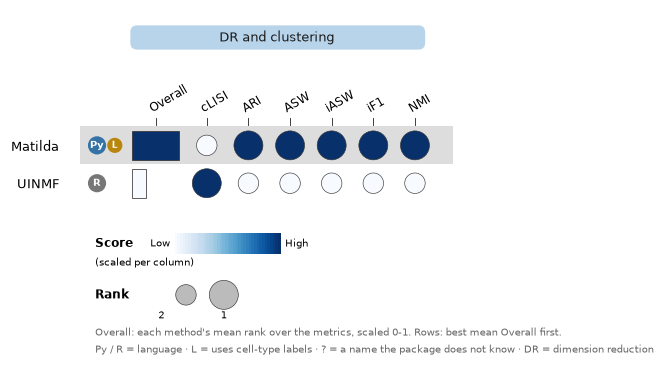

In [5]:
res.plot()

## 5. Your own data

Your data needs raw counts for RNA and protein, an ATAC peak matrix of the same cells and a cell type for each cell. `mtb.io.export_dataset` writes them as a dataset folder, and `run_all` runs on that folder.

<details>
<summary>Details: export</summary>

The folder name, `MYTRI`, is the dataset name for `run_all`, and `data_path` is the folder that holds it.

`mtb.scan("MYTRI", "vertical", data_path="mydata")` checks the folder and the environments without running anything. Its `reason` column says what is missing.

`overwrite=True` replaces the files of an earlier run of this cell. Without it, `export_dataset` raises `FileExistsError` rather than replace a file.

</details>

Here 60% of `D22mini`'s cells take the place of your data:

In [6]:
import scanpy as sc

d = mtb.config.DEFAULT.data_path / "D22mini"
adata = mtb.io.read_canonical(d / "rna.h5")
adata.obsm["protein"] = mtb.io.read_canonical(d / "adt.h5").to_df()
adata.obs["celltype"] = pd.read_csv(d / "cty.csv")["x"].values
atac = mtb.io.read_canonical(d / "atac.h5")
adata = sc.pp.subsample(adata, fraction=0.6, random_state=0, copy=True)
atac = atac[adata.obs_names].copy()
adata, atac

(AnnData object with n_obs × n_vars = 1800 × 1000
     obs: 'celltype'
     obsm: 'protein',
 AnnData object with n_obs × n_vars = 1800 × 5000)

Write the folder, then run the same methods on it:

In [7]:
mtb.io.export_dataset(adata, "mydata/MYTRI", rna="X", adt="obsm:protein", atac=atac,
                      atac_kind="peak", labels="obs:celltype", overwrite=True)

PosixPath('mydata/MYTRI')

In [8]:
mine = mtb.run_all("MYTRI", "vertical", methods=METHODS, data_path="mydata",
                   out_dir="out/MYTRI")
mine.summary

[run_all] Matilda runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] UINMF runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] Matilda (vertical/MYTRI) ...


[run_all]   -> CHAIN_OK (8.6s) ARI 0.788


[run_all] UINMF (vertical/MYTRI) ...


[run_all]   -> CHAIN_OK (16.4s) ARI 0.753


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Matilda,CHAIN_OK,8.6,embedding,"[1800, 100]",10,cty.csv,NaN,None,1,0.7880,0.8153,0.6037,0.6265,0.7500,0.9881,single ordering,,
1,UINMF,CHAIN_OK,16.4,embedding,"[1800, 30]",0,cty.csv,NaN,None,1,0.7526,0.7507,0.5995,0.5790,0.6979,0.9902,single ordering,,


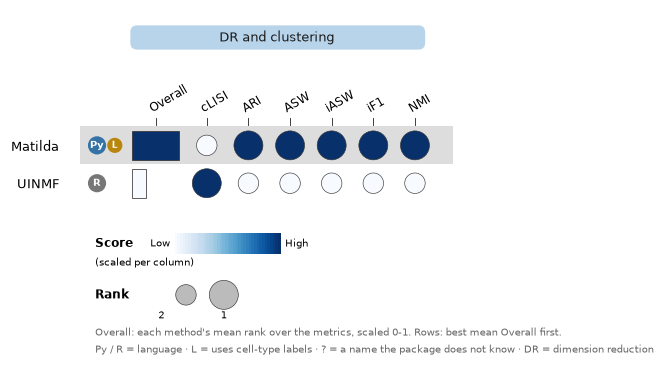

In [9]:
mine.plot()

## 6. Every method of this task

5 methods have a variant for vertical RNA + ADT + ATAC: MOFA2, Matilda, Multigrate, UINMF and scMoMaT. Each runs on `D22mini`. To run them all, set `METHODS` to that list in section 2 and run the notebook again. That downloads 5 envs, 16.4 GB to download on a CPU host, 22.5 GB on a GPU host.

[Every method on `D22mini`](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt_atac_all/) shows that run.

## Troubleshooting

`res.failures` lists each method that failed or was skipped. Its `error` column ends with the method's error output.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `env.install` refuses on macOS or Windows | methods run only on Linux: use Colab or a Linux machine |
| a method needs an NVIDIA GPU | choose a GPU runtime on Colab, or a machine with a GPU |
| a method fails on a small dataset | `mtb.scan` names what the method needs from the data's size in its `caveat` column |
| a warning that values are not whole numbers | export raw counts, for example with `rna="layer:counts"` |
| `... matrix/data as cells x features` | the matrix is transposed: export it again with `mtb.io.export_dataset` |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` scores again without running the methods |

</details>

## Next steps

- `mtb.cite(METHODS)` returns the citations for the benchmark and the methods you ran.
- The other tutorials: [vertical RNA + ADT](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt/), [vertical RNA + ATAC](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_atac/), [diagonal [RNA, ATAC]](https://dsichang.github.io/scMultiBench/tutorials/diagonal_rna_atac/), [diagonal [multiple RNA, multiple ATAC]](https://dsichang.github.io/scMultiBench/tutorials/diagonal_multi/), [mosaic [RNA, RNA + ADT, ADT]](https://dsichang.github.io/scMultiBench/tutorials/mosaic_rna_adt/), [mosaic [RNA, RNA + ATAC, ATAC]](https://dsichang.github.io/scMultiBench/tutorials/mosaic_rna_atac/), [mosaic Mixed, with shared modality](https://dsichang.github.io/scMultiBench/tutorials/mosaic_shared/), [mosaic Mixed, without shared modality](https://dsichang.github.io/scMultiBench/tutorials/mosaic_unshared/), [cross Multiple RNA + ADT](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_adt/), [cross Multiple RNA + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_atac/), [cross Multiple ADT + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_adt_atac/), [cross Multiple RNA + ADT + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_adt_atac/).
- The guides: [run](https://dsichang.github.io/scMultiBench/tutorials/run/), [evaluate](https://dsichang.github.io/scMultiBench/tutorials/evaluate/), [plot](https://dsichang.github.io/scMultiBench/tutorials/plot/) and [discover methods](https://dsichang.github.io/scMultiBench/tutorials/discover/).
- The [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/) has the full benchmark's rankings, with no install needed.